In [34]:
import pandas as pd
import seaborn as sns
from scipy import stats

players = pd.read_csv('../core/People.csv')
teams = pd.read_csv('../core/Teams.csv')
appearances = pd.read_csv('../core/Appearances.csv')
batting = pd.read_csv('../core/Batting.csv')

### How loyal are players to a particular team?

We use the number of different teams for with a single player ever played for as a naive quantifier for loyalty. The histogram shows that among all players in the dataset, it is most common for a single player to play for only one team. The number of players playing for two or more teams decreases roughly geometrically.

<Axes: xlabel='numTeams', ylabel='Count'>

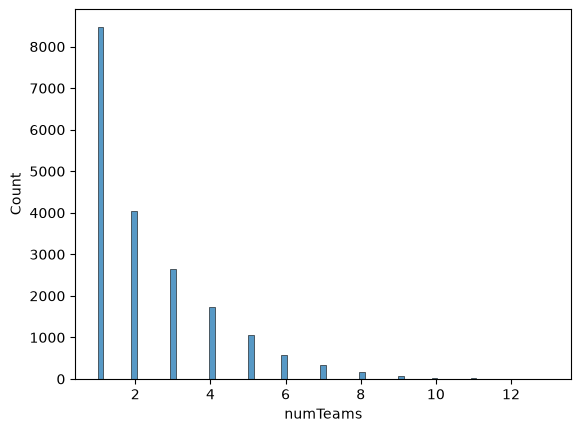

In [13]:
num_teams_per_player = appearances.groupby('playerID')['teamID'].nunique().rename("numTeams")
sns.histplot(x=num_teams_per_player)

### Are players with more career teams more competitive?

<Axes: xlabel='numTeams', ylabel='battingAvg'>

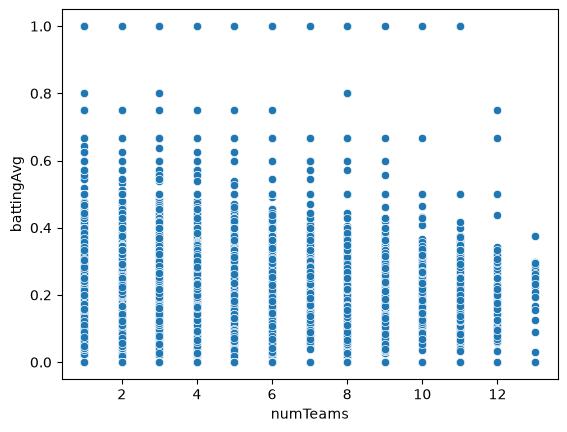

In [46]:
batting['battingAvg'] = batting['H'] / batting['AB']

career_team_perf = pd.merge(batting, num_teams_per_player, on='playerID')[['playerID', 'numTeams', 'battingAvg']]
sns.scatterplot(data=career_team_perf, x='numTeams', y='battingAvg')

<Axes: xlabel='numTeams', ylabel='battingAvg'>

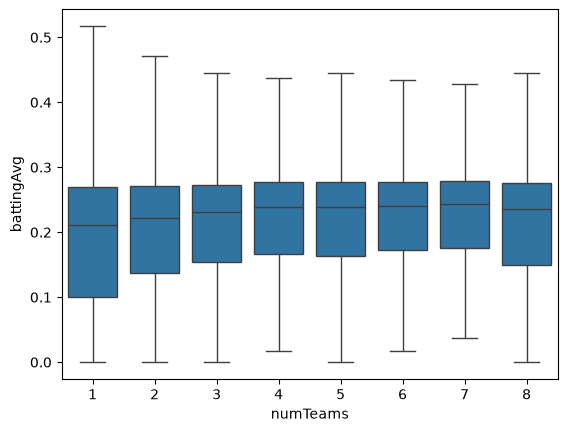

In [47]:
sns.boxplot(x='numTeams', y='battingAvg', data=career_team_perf[career_team_perf['numTeams'] <= 8], showfliers=False)

In [49]:
one_team_perf = career_team_perf[career_team_perf['numTeams'] == 1]['battingAvg']
four_team_perf = career_team_perf[career_team_perf['numTeams'] == 4]['battingAvg']

_, p_value = stats.ttest_ind(one_team_perf, four_team_perf, nan_policy='omit')

print(f"p-value: {p_value}")


p-value: 1.9329285578543515e-49
